# Speen Compare

In the first part, I want to find out to seek the difference in speed between cuda and cpu

Remenber to get your cuda ready if you want to see the difference

In [1]:
from cuda_acc import *  # make sure your python path is in the right directory
import time
import numpy as np

x = np.random.randn(700, 700)
y = np.random.randn(700, 700)

device = cuda if has_cuda() else cpu

assert device is cuda  # this is a cuda speed test

x = device(x)
y = device(y)

print(type(x))
print(type(to_cpu(x)))

t = time.time()

for i in range(10000):
    z = x * y

print(time.time() - t)

t = time.time()

x = to_cpu(x)
y = to_cpu(y)

for i in range(10000):
    z = x * y

print(time.time() - t)

<class 'cupy.ndarray'>
<class 'numpy.ndarray'>
0.16878032684326172
7.892839193344116


# The Set of Variable C

In the second part, I wonder the difference caused by C if the data is not very separable

In [20]:
from sklearn import svm
import numpy as np
import matplotlib.pyplot as plt


def f(C=0.1):
    # 生成500个数据点
    np.random.seed(42)
    n_samples = 500

    # 定义均值和协方差矩阵
    mean1 = [2.6, 2.9]
    mean2 = [1.5, 2]
    mean3 = [3.3, 3.8]
    mean4 = [2.3, 3]
    cov1 = [[0.2, 0], [0, 0.2]]
    cov2 = [[0.1, 0], [0, 0.1]]
    cov3 = [[0.3, 0], [0, 0.3]]
    cov4 = [[0.4, 0], [0, 0.4]]

    # 使用高斯分布生成数据
    X1 = np.random.multivariate_normal(mean1, cov1, int(n_samples / 4))
    X2 = np.random.multivariate_normal(mean2, cov2, int(n_samples / 4))
    X3 = np.random.multivariate_normal(mean3, cov3, int(n_samples / 4))
    X4 = np.random.multivariate_normal(mean4, cov4, int(n_samples / 4))
    X = np.concatenate((X1, X2, X3, X4), axis=0)
    y = np.concatenate((np.zeros(int(n_samples / 4)), np.ones(int(n_samples / 4)),
                        np.zeros(int(n_samples / 4)), np.ones(int(n_samples / 4))))

    # 创建一个SVM分类器对象，启用软间隔
    clf = svm.SVC(C=C, kernel='linear')

    # 拟合数据
    clf.fit(X, y)

    # 绘制散点图
    plt.scatter(X[:, 0], X[:, 1], c=y)

    # 获取超平面的参数
    w = clf.coef_[0]
    b = clf.intercept_[0]

    # 绘制分隔超平面
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx = np.linspace(x_min, x_max, 10)
    yy = -(w[0] * xx + b) / w[1]

    # 绘制直线
    plt.plot(xx, yy, 'k-')

    # 设置图形的范围
    plt.xlim(x_min, x_max)
    plt.ylim(y_min, y_max)

    # 显示图形
    plt.show()


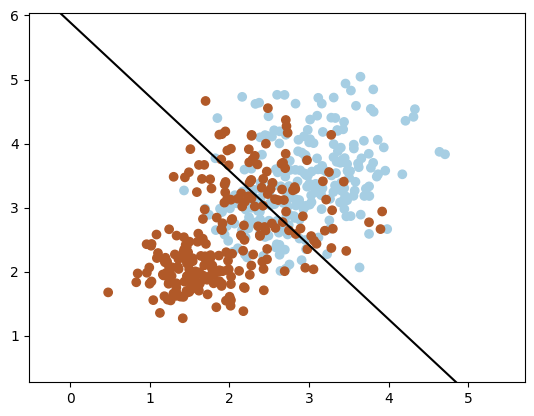

In [21]:
f(0.00000000001)

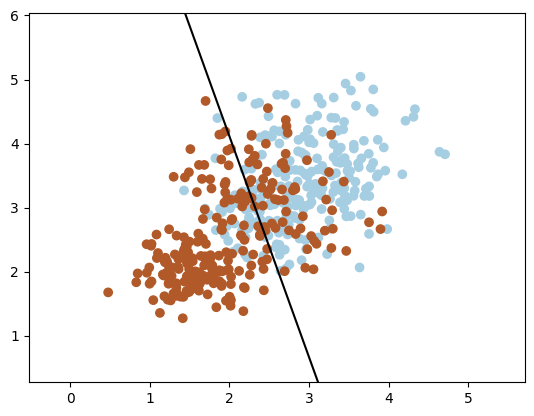

In [22]:
f(1)

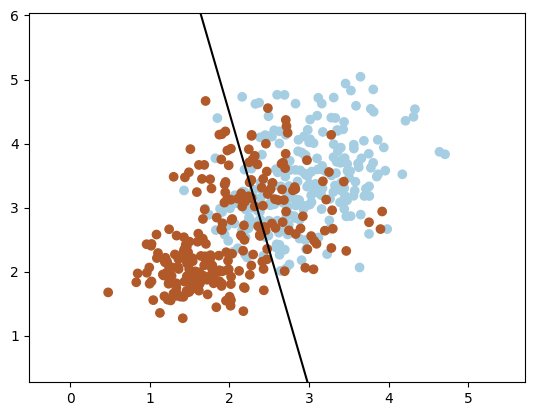

In [23]:
f(100000)

# sklearn baseline

In the third part, I wonder how sklearn can do with mnist and cifar10

In [1]:
import time

In [16]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
from data_loader import load_data
from cuda_acc import cpu

X_train, y_train, X_test, y_test = load_data('mnist', data_path='./data', device=cpu)
y_train, y_test = y_train.flatten(), y_test.flatten()

print(len(X_train), len(X_test), len(y_train), len(y_test))

t = time.time()

svm_model = SVC(kernel="linear")

svm_model.fit(X_train, y_train)

y_pred = svm_model.predict(X_test)

print("时间：", time.time() - t)

accuracy = accuracy_score(y_test, y_pred)
print("准确率:", accuracy)


Data Loaded.
5000 1000 5000 1000
时间： 1.7144832611083984
准确率: 0.893


In [12]:
X_train, y_train, X_test, y_test = load_data('cifar10', data_path='./data', device=cpu)
y_train, y_test = y_train.flatten(), y_test.flatten()

print(len(X_train), len(X_test), len(y_train), len(y_test))

t = time.time()

svm_model = SVC(kernel="rbf")

svm_model.fit(X_train, y_train)

y_pred = svm_model.predict(X_test)

print("时间：", time.time() - t)

accuracy = accuracy_score(y_test, y_pred)
print("准确率:", accuracy)

Files already downloaded and verified
Data Loaded.
5000 1000 5000 1000
时间： 46.15744590759277
准确率: 0.427
